In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample_labels.csv
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/sample_labels.csv
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00006199_010.png
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00003503_000.png
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00017423_004.png
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00022830_001.png
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00016794_000.png
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00010790_035.png
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00015606_039.png
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00005448_001.png
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00025094_000.png
/kaggle/input/data

In [2]:
import os

# Check dataset is attached
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
        

/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample_labels.csv
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/sample_labels.csv
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00006199_010.png
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00003503_000.png
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00017423_004.png
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00022830_001.png
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00016794_000.png
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00010790_035.png
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00015606_039.png
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00005448_001.png
/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample/images/00025094_000.png
/kaggle/input/data

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load CSV
df = pd.read_csv('/kaggle/input/datasets/organizations/nih-chest-xrays/sample/sample_labels.csv')

# Clean age - extract only numbers, ignore letters
df['Patient Age'] = df['Patient Age'].str.extract('(\d+)').astype(int)

print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nMissing Values:\n", df.isnull().sum())
print("\nFirst 5 rows:")
print(df.head())

<>:12: SyntaxWarning: invalid escape sequence '\d'
<>:12: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_22/1503706392.py:12: SyntaxWarning: invalid escape sequence '\d'
  df['Patient Age'] = df['Patient Age'].str.extract('(\d+)').astype(int)


Dataset Shape: (5606, 11)

Column Names: ['Image Index', 'Finding Labels', 'Follow-up #', 'Patient ID', 'Patient Age', 'Patient Gender', 'View Position', 'OriginalImageWidth', 'OriginalImageHeight', 'OriginalImagePixelSpacing_x', 'OriginalImagePixelSpacing_y']

Missing Values:
 Image Index                    0
Finding Labels                 0
Follow-up #                    0
Patient ID                     0
Patient Age                    0
Patient Gender                 0
View Position                  0
OriginalImageWidth             0
OriginalImageHeight            0
OriginalImagePixelSpacing_x    0
OriginalImagePixelSpacing_y    0
dtype: int64

First 5 rows:
        Image Index                                     Finding Labels  \
0  00000013_005.png  Emphysema|Infiltration|Pleural_Thickening|Pneu...   
1  00000013_026.png                             Cardiomegaly|Emphysema   
2  00000017_001.png                                         No Finding   
3  00000030_001.png               

In [4]:
# ============================================
# STEP 2: DISEASE DISTRIBUTION ANALYSIS
# ============================================
from collections import Counter

# Split multi-labels into individual diseases
all_labels = []
for labels in df['Finding Labels']:
    for label in labels.split('|'):
        all_labels.append(label)

# Count each disease
label_counts = Counter(all_labels)
label_df = pd.DataFrame(label_counts.items(), columns=['Disease', 'Count'])
label_df = label_df.sort_values('Count', ascending=False).reset_index(drop=True)

print("Disease Counts:")
print(label_df)

Disease Counts:
               Disease  Count
0           No Finding   3044
1         Infiltration    967
2             Effusion    644
3          Atelectasis    508
4               Nodule    313
5                 Mass    284
6         Pneumothorax    271
7        Consolidation    226
8   Pleural_Thickening    176
9         Cardiomegaly    141
10           Emphysema    127
11               Edema    118
12            Fibrosis     84
13           Pneumonia     62
14              Hernia     13


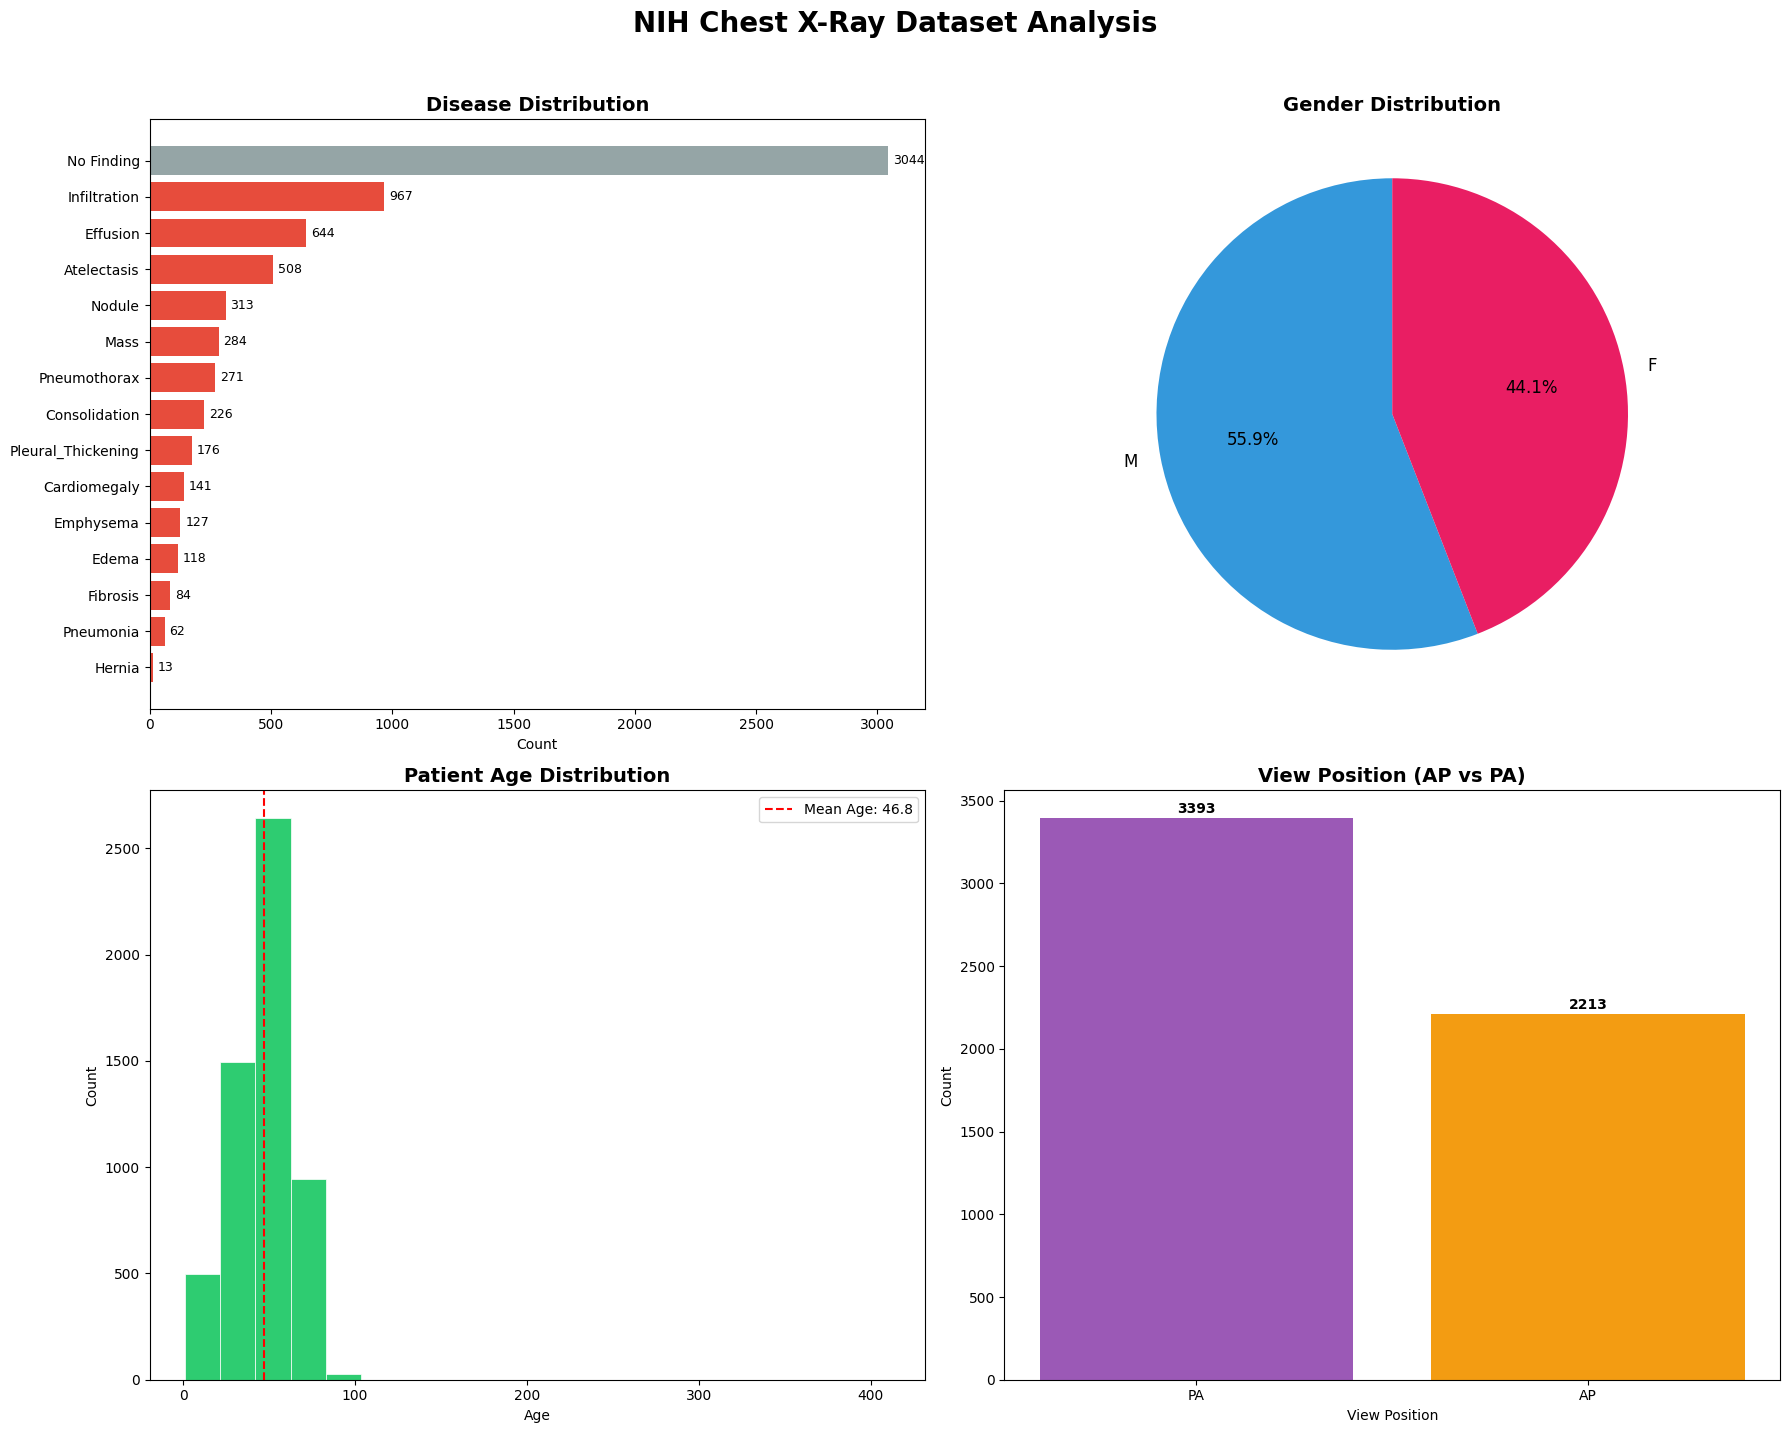

Plot saved successfully!


In [5]:
# ============================================
# STEP 3: VISUALIZATIONS
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('NIH Chest X-Ray Dataset Analysis', fontsize=20, fontweight='bold', y=1.02)

# --- PLOT 1: Disease Distribution ---
ax1 = axes[0, 0]
colors = ['#e74c3c' if d != 'No Finding' else '#95a5a6' for d in label_df['Disease']]
bars = ax1.barh(label_df['Disease'], label_df['Count'], color=colors)
ax1.set_title('Disease Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Count')
for bar, count in zip(bars, label_df['Count']):
    ax1.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
             str(count), va='center', fontsize=9)
ax1.invert_yaxis()

# --- PLOT 2: Gender Distribution ---
ax2 = axes[0, 1]
gender_counts = df['Patient Gender'].value_counts()
ax2.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%',
        colors=['#3498db', '#e91e63'], startangle=90, textprops={'fontsize': 12})
ax2.set_title('Gender Distribution', fontsize=14, fontweight='bold')

# --- PLOT 3: Age Distribution ---
ax3 = axes[1, 0]
ax3.hist(df['Patient Age'], bins=20, color='#2ecc71', edgecolor='white', linewidth=0.5)
ax3.set_title('Patient Age Distribution', fontsize=14, fontweight='bold')
ax3.set_xlabel('Age')
ax3.set_ylabel('Count')
ax3.axvline(df['Patient Age'].mean(), color='red', linestyle='--',
            label=f"Mean Age: {df['Patient Age'].mean():.1f}")
ax3.legend()

# --- PLOT 4: View Position ---
ax4 = axes[1, 1]
view_counts = df['View Position'].value_counts()
ax4.bar(view_counts.index, view_counts.values, color=['#9b59b6', '#f39c12'])
ax4.set_title('View Position (AP vs PA)', fontsize=14, fontweight='bold')
ax4.set_xlabel('View Position')
ax4.set_ylabel('Count')
for i, (pos, count) in enumerate(zip(view_counts.index, view_counts.values)):
    ax4.text(i, count + 30, str(count), ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/eda_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved successfully!")

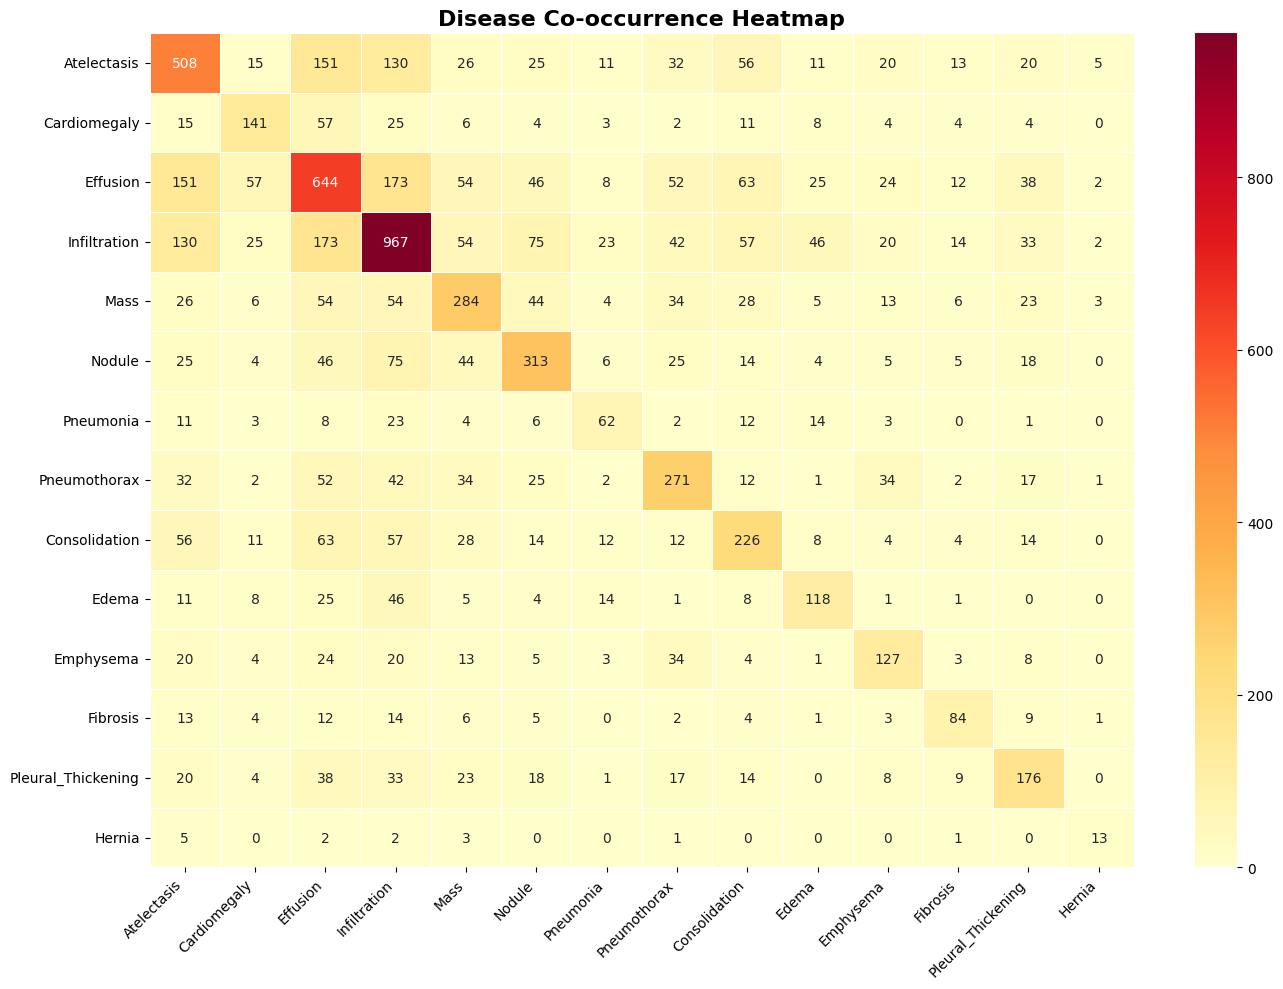

Heatmap saved!


In [6]:
# ============================================
# STEP 4: DISEASE CO-OCCURRENCE HEATMAP
# ============================================

diseases = ['Atelectasis','Cardiomegaly','Effusion','Infiltration',
            'Mass','Nodule','Pneumonia','Pneumothorax','Consolidation',
            'Edema','Emphysema','Fibrosis','Pleural_Thickening','Hernia']

# Create binary columns for each disease
for disease in diseases:
    df[disease] = df['Finding Labels'].apply(lambda x: 1 if disease in x else 0)

# Build co-occurrence matrix
cooccurrence = pd.DataFrame(index=diseases, columns=diseases, data=0)
for _, row in df.iterrows():
    present = [d for d in diseases if row[d] == 1]
    for d1 in present:
        for d2 in present:
            cooccurrence.loc[d1, d2] += 1

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(cooccurrence.astype(int), annot=True, fmt='d',
            cmap='YlOrRd', linewidths=0.5,
            xticklabels=diseases, yticklabels=diseases)
plt.title('Disease Co-occurrence Heatmap', fontsize=16, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('/kaggle/working/cooccurrence_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Heatmap saved!")

# 🫁 NIH Chest X-Ray Dataset — Exploratory Data Analysis

## Project Overview
This notebook performs a comprehensive EDA on the NIH Chest X-Ray dataset 
containing 5,606 frontal-view X-ray images across 14 disease categories.

**Goal:** Understand data distribution, class imbalance, and disease 
co-occurrence patterns before building a multi-label classification model.

**Dataset:** NIH Clinical Center Chest X-Ray Dataset  
**Labels:** NLP-extracted from radiology reports (>90% accuracy)  
**Task:** Multi-label classification (one image can have multiple diseases)

---
## Key Findings
- 🔴 Severe class imbalance: No Finding (3044) vs Hernia (13)
- 📊 Most common disease: Infiltration (967 cases)
- 👤 Mean patient age: 46.8 years, predominantly male (55.9%)
- 🔗 Strongest co-occurrence: Effusion + Infiltration (173 cases)
- ⚠️ Class imbalance justifies use of Focal Loss in model training